<a href="https://colab.research.google.com/github/junsu122/Engineering_industry_contest_2026_computer_visoin/blob/main/%ED%99%94%EC%9E%AC%EA%B0%90%EC%A7%80_%EC%8B%9C%EC%8A%A4%ED%85%9C_%EC%BD%94%EB%93%9C_%EC%88%98%EC%A0%95%EC%A4%91.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

불감지 알고리즘

1. Yolo로 불이난 곳을 감지.
2. 차선의 거리를 파악해서, 카메라를 기준으로 대충 어느정도의 위치에 있는지 확인.
3. 터널의 한 위치를 화점이라고 인식.

## 데이터 다운로드

In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="F59UfNA1KigRh39tGVxr")
project = rf.workspace("stilez1").project("some-and-fire-detection")
version = project.version(3)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 46.4 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Some-and-Fire-Detection-3 in yolov8:: 100%|██████████| 7888/7888 [00:01<00:00, 6394.80it/s]


## 인식프로그램(Yolov8) 다운

In [ ]:
# Ultralytics 패키지 설치
!pip install ultralytics

from ultralytics import YOLO
import os

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 8.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 테스트 학습
- learning rate와 weight_decay를 많이 주지 않았음.

In [ ]:
# 1. 모델 불러오기 (미리 학습된 가중치 사용)
model = YOLO('yolov8n.pt')

# 1. 학습 실행 (결과를 변수 'results'에 저장)
results = model.train(
    data='/content/Some-and-Fire-Detection-3/data.yaml',
    epochs=50,
    imgsz=480,
    device=0,
    optimizer='AdamW',  # 여기서 지정! (SGD, Adam, AdamW, RMSProp 등 가능)
    lr0=0.1,           # 초기 학습률 (Initial Learning Rate)
    momentum=0.8,     # 모멘텀 값
    weight_decay=0.005, # 가중치 감쇠
    project='/content/training_results',
    name='fire_detection'
)

# 2. 결과 폴더 경로 확인 (보통 /content/training_results/fire_detection/ 에 저장됨)
results_dir = results.save_dir

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Some-and-Fire-Detection-3/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=480, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.1, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.8, mosaic=1.0, multi_scale=0.0, name=fire_detection3, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patie

시각화

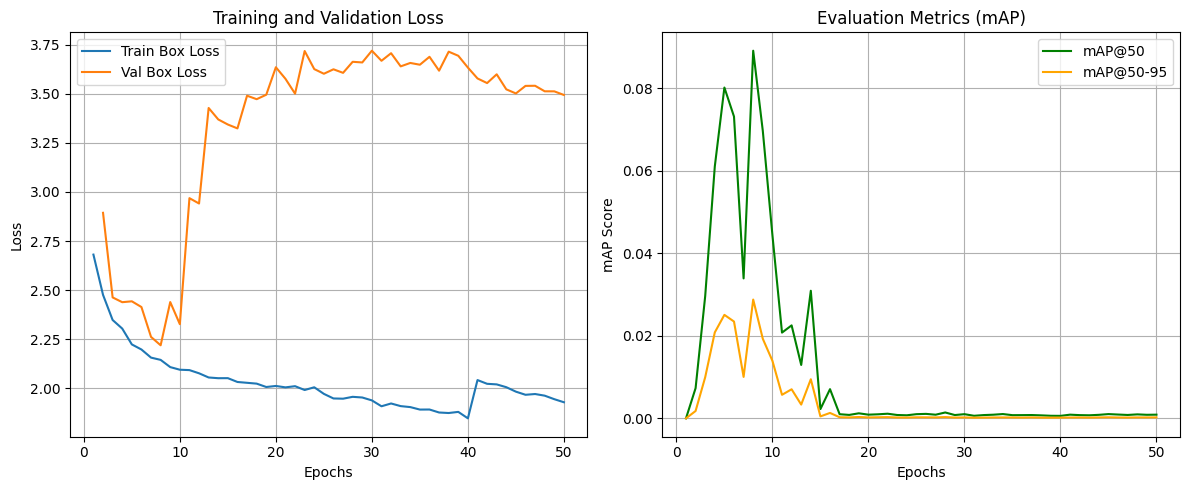

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# csv 파일 경로 설정
csv_path = os.path.join(results_dir, 'results.csv')
df = pd.read_csv(csv_path)

# 컬럼명 앞뒤 공백 제거
df.columns = df.columns.str.strip()

# 그래프 그리기
plt.figure(figsize=(12, 5))

# 1. Loss 그래프 (Train vs Valid)
plt.subplot(1, 2, 1)
plt.plot(df['epoch'], df['train/box_loss'], label='Train Box Loss')
plt.plot(df['epoch'], df['val/box_loss'], label='Val Box Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 2. mAP (Accuracy 대용) 그래프
plt.subplot(1, 2, 2)
# mAP50은 정확도와 가장 유사한 지표입니다.
plt.plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@50', color='green')
plt.plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@50-95', color='orange')
plt.title('Evaluation Metrics (mAP)')
plt.xlabel('Epochs')
plt.ylabel('mAP Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

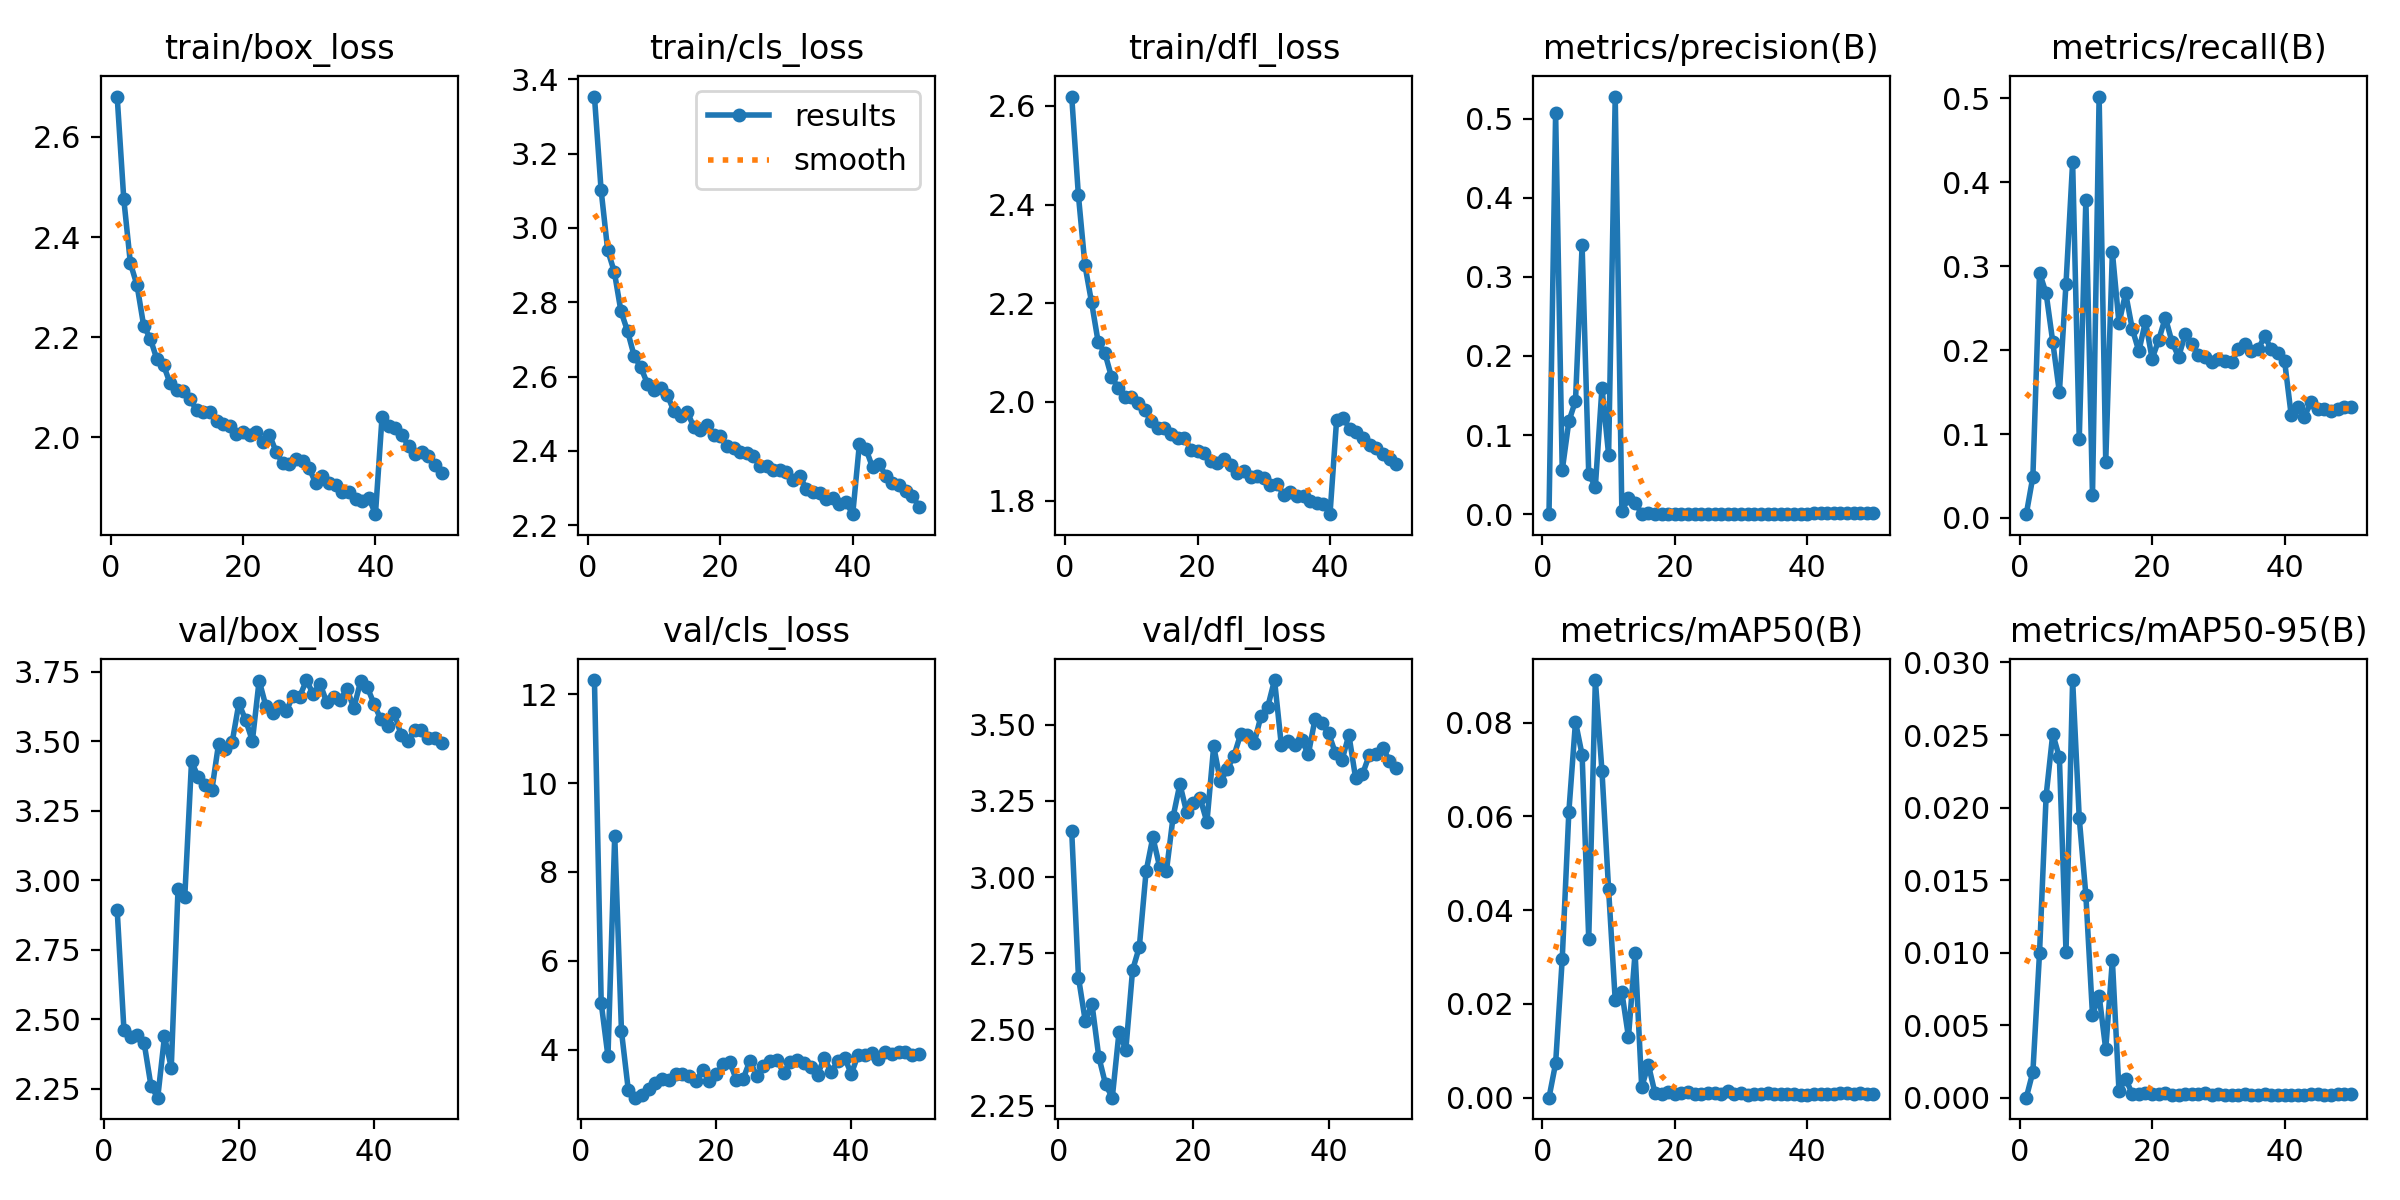

In [ ]:
from IPython.display import Image
Image(filename=f'{results_dir}/results.png')

## 학습상태 확인
- map가 0에 수렴해버려서 사실상 의미 없음

Found 30 images for testing.
Predicting on: FireDetectionImage_NoiseWEBFire950_jpg.rf.d84f69de0130a58ce59d9b6c32c6beba.jpg

image 1/1 /content/Some-and-Fire-Detection-3/test/images/FireDetectionImage_NoiseWEBFire950_jpg.rf.d84f69de0130a58ce59d9b6c32c6beba.jpg: 480x480 (no detections), 5.6ms
Speed: 1.5ms preprocess, 5.6ms inference, 0.5ms postprocess per image at shape (1, 3, 480, 480)


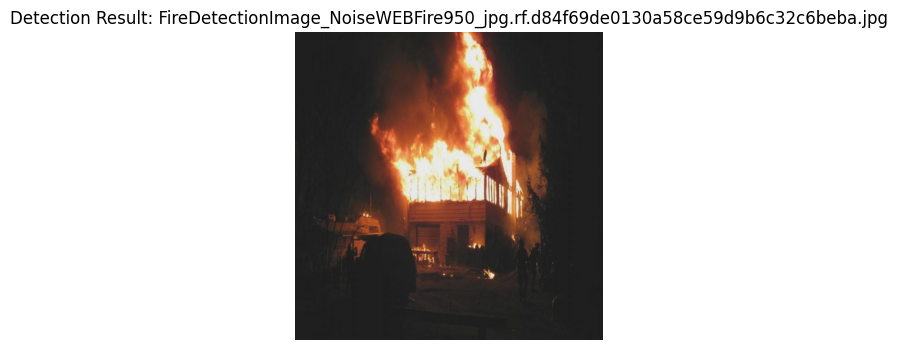

Predicting on: eb380_jpg.rf.e4ad49b09ec294d9a0def115011b9d8c.jpg

image 1/1 /content/Some-and-Fire-Detection-3/test/images/eb380_jpg.rf.e4ad49b09ec294d9a0def115011b9d8c.jpg: 480x480 (no detections), 9.9ms
Speed: 4.1ms preprocess, 9.9ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 480)


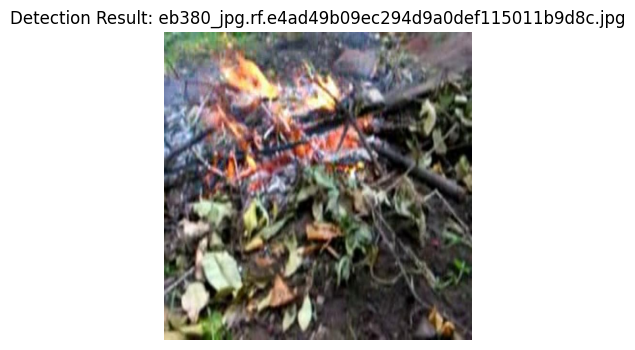

Predicting on: Datacluster-Fire-and-Smoke-Sample--25-_jpg.rf.c54d65d9c3721a64d0dee480e6fc7ea0.jpg

image 1/1 /content/Some-and-Fire-Detection-3/test/images/Datacluster-Fire-and-Smoke-Sample--25-_jpg.rf.c54d65d9c3721a64d0dee480e6fc7ea0.jpg: 480x480 (no detections), 9.4ms
Speed: 2.7ms preprocess, 9.4ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 480)


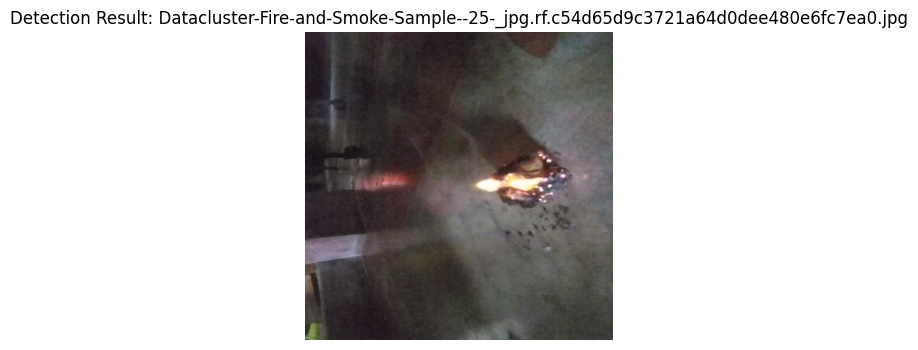

Inference and visualization with bounding boxes complete.


In [ ]:
import cv2
import glob
import os
import matplotlib.pyplot as plt
from ultralytics import YOLO
from pylab import rcParams

# 1. 그래프 크기 설정 (코랩 화면에 크게 보이게)
rcParams['figure.figsize'] = 4,4

# 2. 학습된 베스트 모델 불러오기
# 학습 결과 폴더 내 weights/best.pt 파일 경로를 정확히 입력하세요.
model_path = '/content/training_results/fire_detection3/weights/best.pt'
model = YOLO(model_path)

# 3. 테스트할 이미지 데이터 경로 설정
# 테스트용 이미지들이 모여있는 폴더 경로를 입력하세요.
test_images_dir = '/content/Some-and-Fire-Detection-3/test/images'

# 폴더 내 이미지 파일 목록 가져오기 (jpg, png 등)
image_files = glob.glob(os.path.join(test_images_dir, '*.jpg')) + \
              glob.glob(os.path.join(test_images_dir, '*.png'))

# 테스트 이미지가 없는 경우 예외 처리
if not image_files:
    print(f"Error: No images found in {test_images_dir}")
else:
    print(f"Found {len(image_files)} images for testing.")

    # 4. 이미지에 대해 예측 수행 및 Bounding Box 시각화
    # 무작위로 3장만 뽑아서 테스트 (이미지가 많을 경우)
    import random
    test_sample = random.sample(image_files, min(3, len(image_files)))

    for img_path in test_sample:
        print(f"Predicting on: {os.path.basename(img_path)}")

        # 예측 실행 (conf=0.25는 신뢰도 25% 이상만 표시)
        # Bounding Box 정보를 포함한 결과 객체를 반환받습니다.
        results = model.predict(source=img_path, conf=0.25)

        # results[0]는 첫 번째 이미지에 대한 결과입니다.
        result = results[0]

        # 5. Ultralytics의 plot() 기능을 사용하여 Bounding Box가 그려진 이미지 생성
        # plot() 함수는 Bounding Box, 라벨, 신뢰도를 모두 포함한 이미지를 반환합니다.
        annotated_frame = result.plot()

        # 6. OpenCV 이미지를 Matplotlib 형식으로 변환 (BGR -> RGB)
        annotated_frame_rgb = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)

        # 7. 코랩 화면에 출력
        plt.imshow(annotated_frame_rgb)
        plt.title(f"Detection Result: {os.path.basename(img_path)}")
        plt.axis('off') # 축 숨기기
        plt.show()

print("Inference and visualization with bounding boxes complete.")

## 성능이 미흡함. 다른 불은 인식 되는지 확인해보고, 다시 학습하기 결정.
- learning rate가 너무 크고
- 데이터증강이 필요해보임
- map가 0에 수렴해서 사실상 아무것도 인식못함. 다시해야함.